In [1]:
import warnings
warnings.filterwarnings("ignore")

In [46]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB()
}

df = pd.read_csv("Attendance_Prediction.csv")



In [3]:
df.head()


,student_id,age,gender,course,year,parent_education,internet_access,hostel_resident,class_type,weather,study_hours,sleep_hours,travel_time_minutes,attendance,absence_reason
0,200.99,17,male,pharmacy,1st year,high school,no,yes,offline,sunny,3.63,7.24,31,1,none
1,200.99,23,other,diploma,2nd year,high school,yes,yes,offline,cloudy,4.39,7.98,50,0,no reason
2,200.99,22,male,b.sc,3rd year,no formal,yes,yes,online,rainy,5.43,6.53,62,1,none
3,200.99,20,other,pharmacy,2nd year,no formal,yes,yes,offline,cloudy,0.21,7.11,63,0,personal work
4,200.99,20,female,pharmacy,1st year,no formal,yes,yes,online,sunny,1.77,9.35,81,0,project work


In [4]:
df.drop(columns=['student_id'], inplace=True)
df.head()


,age,gender,course,year,parent_education,internet_access,hostel_resident,class_type,weather,study_hours,sleep_hours,travel_time_minutes,attendance,absence_reason
0,17,male,pharmacy,1st year,high school,no,yes,offline,sunny,3.63,7.24,31,1,none
1,23,other,diploma,2nd year,high school,yes,yes,offline,cloudy,4.39,7.98,50,0,no reason
2,22,male,b.sc,3rd year,no formal,yes,yes,online,rainy,5.43,6.53,62,1,none
3,20,other,pharmacy,2nd year,no formal,yes,yes,offline,cloudy,0.21,7.11,63,0,personal work
4,20,female,pharmacy,1st year,no formal,yes,yes,online,sunny,1.77,9.35,81,0,project work


In [5]:
df.columns


Index(['age', 'gender', 'course', 'year', 'parent_education',
       'internet_access', 'hostel_resident', 'class_type', 'weather',
       'study_hours', 'sleep_hours', 'travel_time_minutes', 'attendance',
       'absence_reason'],
      dtype='object')

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df.head()


,age,gender,course,year,parent_education,internet_access,hostel_resident,class_type,weather,study_hours,sleep_hours,travel_time_minutes,attendance,absence_reason
0,17,1,8,0,1,0,1,0,4,3.63,7.24,31,1,2
1,23,2,6,1,1,1,1,0,0,4.39,7.98,50,0,1
2,22,1,1,2,2,1,1,1,3,5.43,6.53,62,1,2
3,20,2,8,1,2,1,1,0,0,0.21,7.11,63,0,3
4,20,0,8,0,2,1,1,1,4,1.77,9.35,81,0,4


In [7]:
X = df.drop("attendance", axis=1)
y = df["attendance"]


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)


In [10]:
from sklearn.metrics import accuracy_score

train_results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    train_results.append([name, acc])

train_df = pd.DataFrame(train_results, columns=["Model", "Accuracy"])
train_df

,Model,Accuracy
0,Logistic Regression,0.69425
1,KNN,0.75725
2,Decision Tree,0.87000
3,Random Forest,0.92675
4,SVM,0.86775
5,Naive Bayes,0.92750


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import mean_squared_error, r2_score

models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    results.append([name, acc, precision, recall, f1])

import pandas as pd
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])
results_df


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.69425,0.669939,0.797468,0.728162
1,KNN,0.75725,0.702733,0.913827,0.794497
2,Decision Tree,0.87500,0.880137,0.875852,0.877989
3,Random Forest,0.92725,0.876227,0.999513,0.933819
4,SVM,0.86775,0.797503,0.995131,0.885423
5,Naive Bayes,0.92750,0.876280,1.000000,0.934061


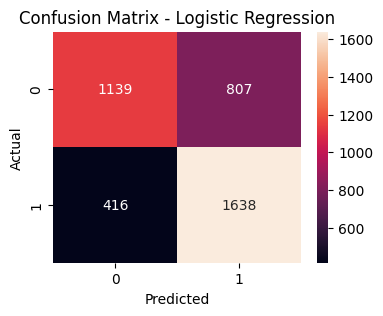

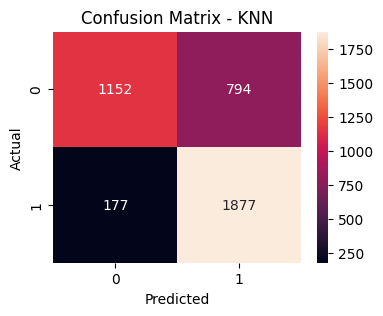

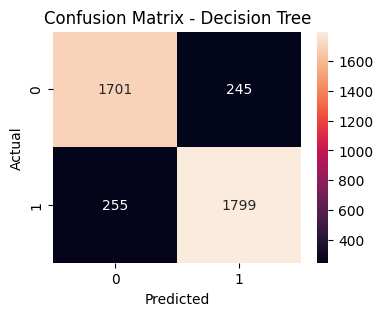

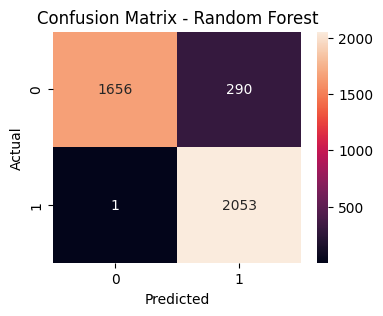

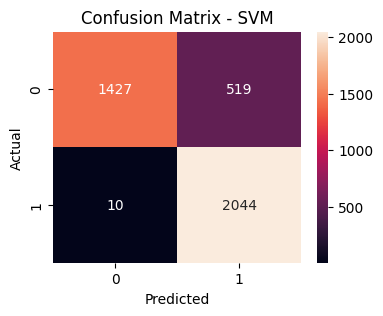

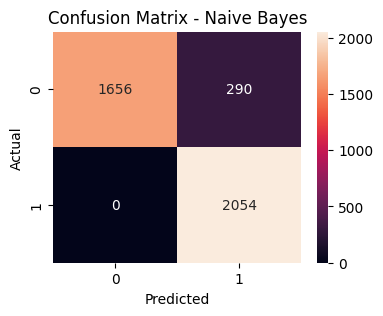

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

for name, model in models.items():
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)

    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

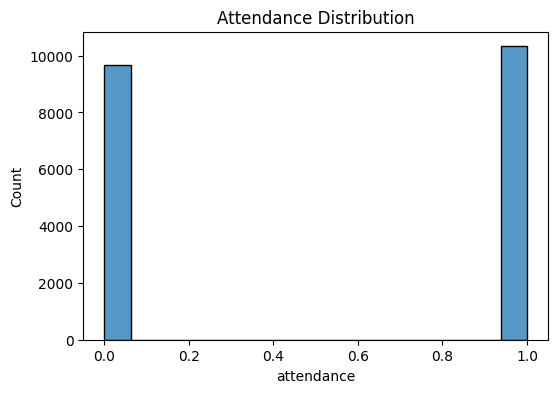

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(df['attendance'])
plt.title("Attendance Distribution")
plt.show()


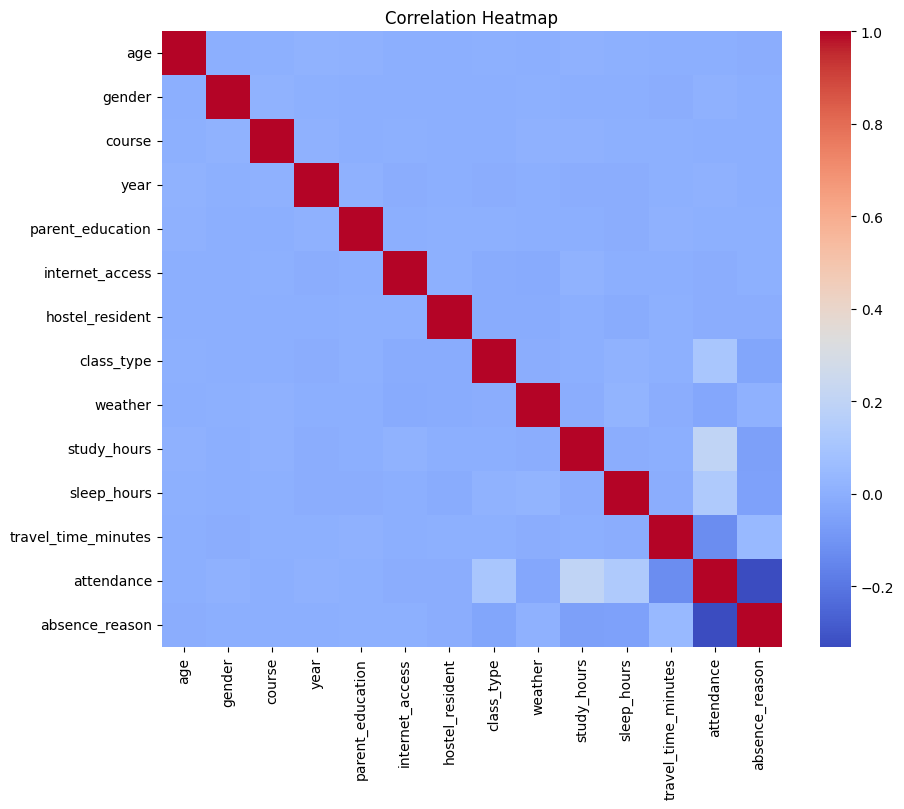

In [14]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [15]:
results_df


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.69425,0.669939,0.797468,0.728162
1,KNN,0.75725,0.702733,0.913827,0.794497
2,Decision Tree,0.87500,0.880137,0.875852,0.877989
3,Random Forest,0.92725,0.876227,0.999513,0.933819
4,SVM,0.86775,0.797503,0.995131,0.885423
5,Naive Bayes,0.92750,0.876280,1.000000,0.934061


In [16]:
from sklearn.model_selection import cross_val_score

cv_results = []

for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')
    cv_results.append([name, scores.mean()])

import pandas as pd
cv_df = pd.DataFrame(cv_results, columns=["Model", "5-Fold CV Accuracy"])
cv_df

,Model,5-Fold CV Accuracy
0,Logistic Regression,0.69315
1,KNN,0.76590
2,Decision Tree,0.87665
3,Random Forest,0.93270
4,SVM,0.87775
5,Naive Bayes,0.93325


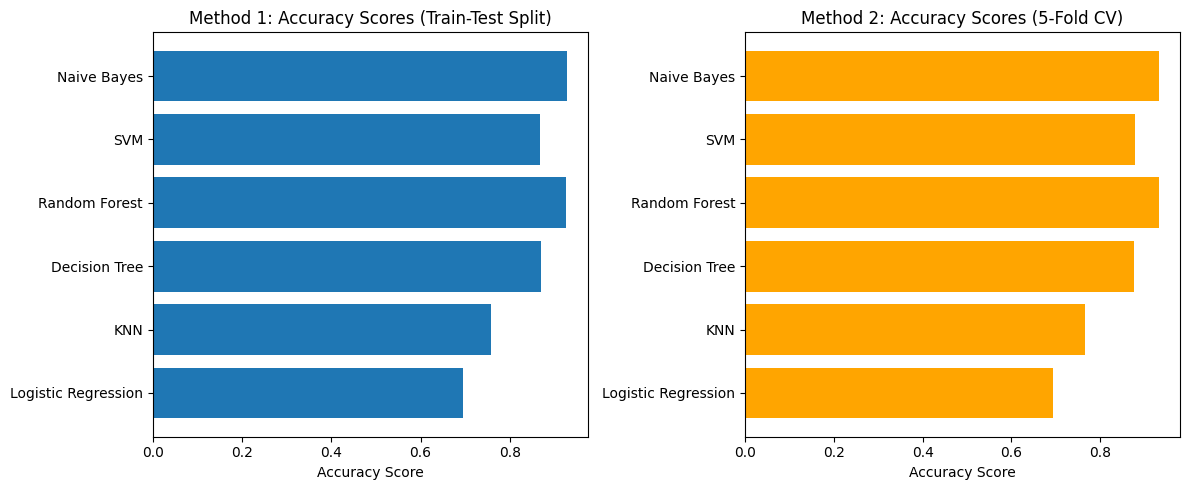

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Train-Test Plot
plt.subplot(1,2,1)
plt.barh(train_df["Model"], train_df["Accuracy"])
plt.title("Method 1: Accuracy Scores (Train-Test Split)")
plt.xlabel("Accuracy Score")

# Cross Validation Plot
plt.subplot(1,2,2)
plt.barh(cv_df["Model"], cv_df["5-Fold CV Accuracy"], color="orange")
plt.title("Method 2: Accuracy Scores (5-Fold CV)")
plt.xlabel("Accuracy Score")

plt.tight_layout()
plt.show()

In [18]:
# Remove target column
X_cluster = df.drop("attendance", axis=1)

# Scale features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled_cluster = scaler.fit_transform(X_cluster)

In [19]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled_cluster)

df["KMeans_Cluster"] = kmeans_labels

df["KMeans_Cluster"].value_counts()

,count
KMeans_Cluster,
1,7033
2,6913
0,6054


In [20]:
from sklearn.cluster import AgglomerativeClustering

hier = AgglomerativeClustering(n_clusters=3)
hier_labels = hier.fit_predict(X_scaled_cluster)

df["Hierarchical_Cluster"] = hier_labels

df["Hierarchical_Cluster"].value_counts()

,count
Hierarchical_Cluster,
0,11824
2,4207
1,3969


In [21]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled_cluster)

df["DBSCAN_Cluster"] = dbscan_labels

df["DBSCAN_Cluster"].value_counts()

,count
DBSCAN_Cluster,
-1,15359
0,2448
2,415
18,175
46,41
...,...
185,2
184,2
176,2


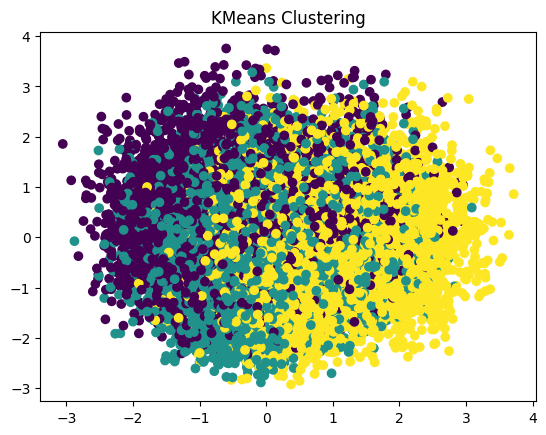

In [22]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_cluster)

plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels)
plt.title("KMeans Clustering")
plt.show()

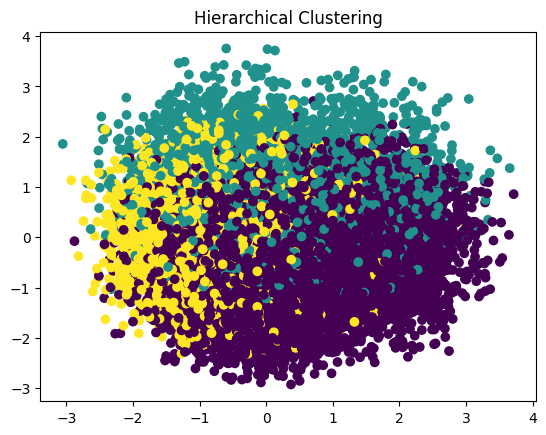

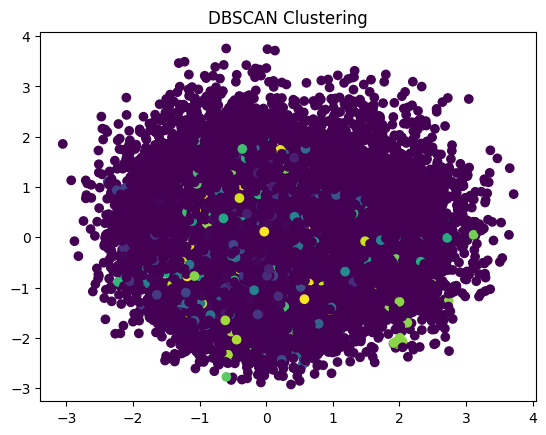

In [23]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=hier_labels)
plt.title("Hierarchical Clustering")
plt.show()

plt.scatter(X_pca[:,0], X_pca[:,1], c=dbscan_labels)
plt.title("DBSCAN Clustering")
plt.show()

In [24]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [25]:
model = Sequential()

model.add(Dense(32, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [26]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [27]:
history = model.fit(X_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_split=0.2)

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6971 - loss: 0.5674 - val_accuracy: 0.8369 - val_loss: 0.4047
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9115 - loss: 0.2791 - val_accuracy: 0.9369 - val_loss: 0.2082
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9340 - loss: 0.2099 - val_accuracy: 0.9378 - val_loss: 0.1929
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9337 - loss: 0.2017 - val_accuracy: 0.9378 - val_loss: 0.1906
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9341 - loss: 0.1990 - val_accuracy: 0.9375 - val_loss: 0.1876
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9340 - loss: 0.1968 - val_accuracy: 0.9378 - val_loss: 0.1886
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9343 - loss: 0.1957 - val_accuracy: 0.9378 - val_loss: 0.1871
Epoch 8/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9341 - loss: 0.1950 - val_accuracy: 0.

In [28]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy:", accuracy)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9273 - loss: 0.2140
Accuracy: 0.9272500276565552


In [29]:
y_pred = (model.predict(X_test) > 0.5).astype(int)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [30]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.85      0.92      1946
           1       0.88      1.00      0.93      2054

    accuracy                           0.93      4000
   macro avg       0.94      0.93      0.93      4000
weighted avg       0.94      0.93      0.93      4000



In [45]:
!pip install mlxtend
from mlxtend.frequent_patterns import apriori, association_rules

In [44]:
df_arm = df.copy()

# Convert everything to binary (important)
df_arm = df_arm.apply(lambda x: x > x.mean()).astype(int)

In [43]:
frequent_items = apriori(df_arm, min_support=0.2, use_colnames=True)
frequent_items.head()

,support,itemsets
0,0.49640,(age)
1,0.33630,(gender)
2,0.44365,(course)
3,0.50260,(year)
4,0.40135,(parent_education)


In [42]:
rules = association_rules(frequent_items, metric="confidence", min_threshold=0.6)
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(age),(internet_access),0.49640,0.80145,0.39795,0.801672,1.000277,1.0,0.000110,1.001120,0.000550,0.442216,0.001118,0.649105
1,(gender),(internet_access),0.33630,0.80145,0.26995,0.802706,1.001567,1.0,0.000422,1.006366,0.002357,0.311074,0.006325,0.569766
2,(course),(internet_access),0.44365,0.80145,0.35530,0.800857,0.999260,1.0,-0.000263,0.997020,-0.001330,0.399303,-0.002989,0.622089
3,(year),(internet_access),0.50260,0.80145,0.40210,0.800040,0.998240,1.0,-0.000709,0.992948,-0.003531,0.445812,-0.007103,0.650878
4,(parent_education),(internet_access),0.40135,0.80145,0.32030,0.798057,0.995766,1.0,-0.001362,0.983196,-0.007053,0.362946,-0.017091,0.598854


In [41]:
print("Student Recommendations:\n")

for i in range(10):  # first 10 students

    attendance = df['attendance'].iloc[i]

    if attendance == 0:
        print(f"Student {i} (Low Attendance):")
        print("- Attend extra classes")
        print("- Assign mentor guidance")
        print("- Regular attendance monitoring")
        print("- Provide academic support\n")

    else:
        print(f"Student {i} (Good Attendance):")
        print("- Participate in hackathons")
        print("- Recommend advanced learning resources")
        print("- Assign leadership roles")
        print("- Maintain performance\n")

Student Recommendations:

Student 0 (Good Attendance):
- Participate in hackathons
- Recommend advanced learning resources
- Assign leadership roles
- Maintain performance

Student 1 (Low Attendance):
- Attend extra classes
- Assign mentor guidance
- Regular attendance monitoring
- Provide academic support

Student 2 (Good Attendance):
- Participate in hackathons
- Recommend advanced learning resources
- Assign leadership roles
- Maintain performance

Student 3 (Low Attendance):
- Attend extra classes
- Assign mentor guidance
- Regular attendance monitoring
- Provide academic support

Student 4 (Low Attendance):
- Attend extra classes
- Assign mentor guidance
- Regular attendance monitoring
- Provide academic support

Student 5 (Good Attendance):
- Participate in hackathons
- Recommend advanced learning resources
- Assign leadership roles
- Maintain performance

Student 6 (Good Attendance):
- Participate in hackathons
- Recommend advanced learning resources
- Assign leadership roles
- 

In [47]:
# Extract Random Forest accuracy (ensemble model)
rf_acc = results_df[results_df["Model"] == "Random Forest"]["Accuracy"].values[0]

print("\n===== FINAL MODEL COMPARISON =====")
print(f"Random Forest (ML - Ensemble) Accuracy: {rf_acc}")
print(f"Neural Network (Deep Learning) Accuracy: {accuracy}")


===== FINAL MODEL COMPARISON =====
Random Forest (ML - Ensemble) Accuracy: 0.92725
Neural Network (Deep Learning) Accuracy: 0.9272500276565552
